<a href="https://colab.research.google.com/github/jasonkjw/daily_coding_commit/blob/main/climate_comparision.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

Mounted at /content/drive

[ HVAC 설계 외기온도 분석 요약 ]
   City  Cooling 0.4% (°C)  Heating 0.4% (°C)  Mean (°C)  Std Dev
  Busan               31.8               -5.5      15.20     8.50
Gwangju               33.2               -6.8      14.47     9.89
  Ulsan               33.3               -6.3      14.64     9.18

그래프가 저장되었습니다: /content/drive/MyDrive/HVAC_Comparison_Result.png


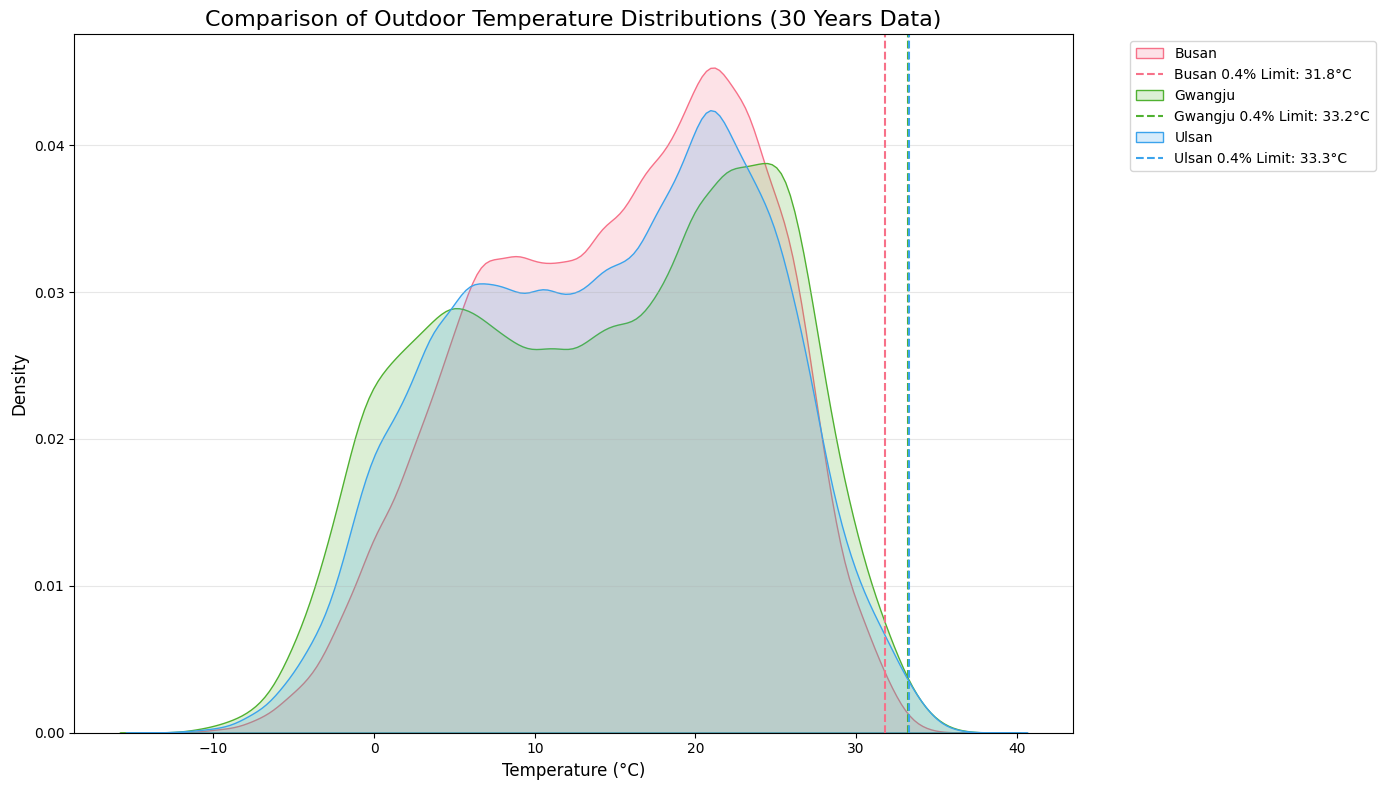

In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import os
from google.colab import drive

# 1. 구글 드라이브 마운트
drive.mount('/content/drive')

def analyze_hvac_temperatures(file_dict):
    """
    여러 도시의 CSV 파일을 받아 전처리하고 통계치 및 그래프를 생성합니다.
    file_dict: {'도시명': '파일경로'} 형태의 딕셔너리
    """
    all_data = []
    summary_stats = []

    # 그래프 설정
    plt.figure(figsize=(14, 8))
    colors = sns.color_palette("husl", len(file_dict))

    for i, (city_name, file_path) in enumerate(file_dict.items()):
        if not os.path.exists(file_path):
            print(f"경고: {city_name}의 파일을 찾을 수 없습니다 ({file_path})")
            continue

        # 데이터 로드
        df = pd.read_csv(file_path)

        # 01~24시 컬럼 추출 및 직렬화
        hourly_cols = [f'{i:02d}' for i in range(1, 25)]
        temp_series = df[hourly_cols].stack()

        # 결측치(-99.0 및 NaN) 제거
        temp_series = temp_series[temp_series != -99.0].dropna()

        # 통계치 계산
        cooling_04 = temp_series.quantile(0.996) # 상위 0.4%
        heating_04 = temp_series.quantile(0.004) # 하위 0.4%
        mean_temp = temp_series.mean()
        std_dev = temp_series.std()

        summary_stats.append({
            'City': city_name,
            'Cooling 0.4% (°C)': round(cooling_04, 2),
            'Heating 0.4% (°C)': round(heating_04, 2),
            'Mean (°C)': round(mean_temp, 2),
            'Std Dev': round(std_dev, 2)
        })

        # 분포 시각화 (KDE Plot)
        sns.kdeplot(temp_series, label=city_name, fill=True, alpha=0.2, color=colors[i])

        # 설계 온도 지점에 수직선 표시
        plt.axvline(cooling_04, color=colors[i], linestyle='--', linewidth=1.5,
                    label=f'{city_name} 0.4% Limit: {cooling_04:.1f}°C')

    # 결과 표 출력
    stats_df = pd.DataFrame(summary_stats)
    print("\n[ HVAC 설계 외기온도 분석 요약 ]")
    print(stats_df.to_string(index=False))

    # 그래프 세부 설정
    plt.title('Comparison of Outdoor Temperature Distributions (30 Years Data)', fontsize=16)
    plt.xlabel('Temperature (°C)', fontsize=12)
    plt.ylabel('Density', fontsize=12)
    plt.legend(bbox_to_anchor=(1.05, 1), loc='upper left') # 범례를 그래프 밖에 표시
    plt.grid(axis='y', alpha=0.3)
    plt.tight_layout()
    plt.show()

# ---------------------------------------------------------
# 사용 예시: 분석하고 싶은 도시명과 파일 경로를 입력하세요.
# ---------------------------------------------------------
base_path = '/content/drive/MyDrive/'
target_files = {
    'Busan': base_path + 'Busan_STN_DATA.csv',
    'Gwangju': base_path + 'Gwangju_STN_DATA.csv',
    'Ulsan': base_path + 'ULsan_STN_DATA.csv'
    # 'Seoul': base_path + 'Seoul_STN_DATA.csv'  <-- 추가하고 싶을 때 주석 해제
}

analyze_hvac_temperatures(target_files)